<a href="https://colab.research.google.com/github/Dharshini13002/Machine-learning-codes/blob/main/VGG16ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ambarish/wangdataset")

print("Path to dataset files:", path)

100%|██████████| 56.9M/56.9M [00:03<00:00, 15.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ambarish/wangdataset/versions/1


In [48]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model

def vgg16_model(input_shape=(224, 224, 3), num_classes=1000):
    """
    Defines the VGG16 convolutional neural network architecture.

    Args:
        input_shape (tuple): The shape of the input images (height, width, channels).
        num_classes (int): The number of output classes.

    Returns:
        tf.keras.models.Model: The VGG16 model.
    """
    input_tensor = Input(shape=input_shape)

    # Block 1
    x = Conv2D(64, (3, 3), activation='relu', padding='same', name='block1_conv1')(input_tensor)
    x = Conv2D(64, (3, 3), activation='relu', padding='same', name='block1_conv2')(x)
    x = MaxPooling2D((2, 2), strides=(2, 2), name='block1_pool')(x)

    # Block 2
    x = Conv2D(128, (3, 3), activation='relu', padding='same', name='block2_conv1')(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same', name='block2_conv2')(x)
    x = MaxPooling2D((2, 2), strides=(2, 2), name='block2_pool')(x)

    # Block 3
    x = Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv1')(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv2')(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv3')(x)
    x = MaxPooling2D((2, 2), strides=(2, 2), name='block3_pool')(x)

    # Block 4
    x = Conv2D(512, (3, 3), activation='relu', padding='same', name='block4_conv1')(x)
    x = Conv2D(512, (3, 3), activation='relu', padding='same', name='block4_conv2')(x)
    x = Conv2D(512, (3, 3), activation='relu', padding='same', name='block4_conv3')(x)
    x = MaxPooling2D((2, 2), strides=(2, 2), name='block4_pool')(x)

    # Block 5
    x = Conv2D(512, (3, 3), activation='relu', padding='same', name='block5_conv1')(x)
    x = Conv2D(512, (3, 3), activation='relu', padding='same', name='block5_conv2')(x)
    x = Conv2D(512, (3, 3), activation='relu', padding='same', name='block5_conv3')(x)
    x = MaxPooling2D((2, 2), strides=(2, 2), name='block5_pool')(x)

    # Classification block
    x = Flatten(name='flatten')(x)
    x = Dense(4096, activation='relu', name='fc1')(x)
    x = Dense(4096, activation='relu', name='fc2')(x)
    x = Dense(num_classes, activation='softmax', name='predictions')(x)

    model = Model(inputs=input_tensor, outputs=x, name='vgg16')
    return model

# Get the number of unique classes from the dataset
# Based on the output of cell Rq_X6GDTAgBa, there are 2 classes
num_classes_dataset = 2

# Create an instance of the VGG16 model with the correct number of classes
vgg16 = vgg16_model(num_classes=num_classes_dataset)

# Print the model summary
vgg16.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,268,738 (512.19 MB)

 Trainable params: 134,268,738 (512.19 MB)

 Non-trainable params: 0 (0.00 B)

32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 172ms/step


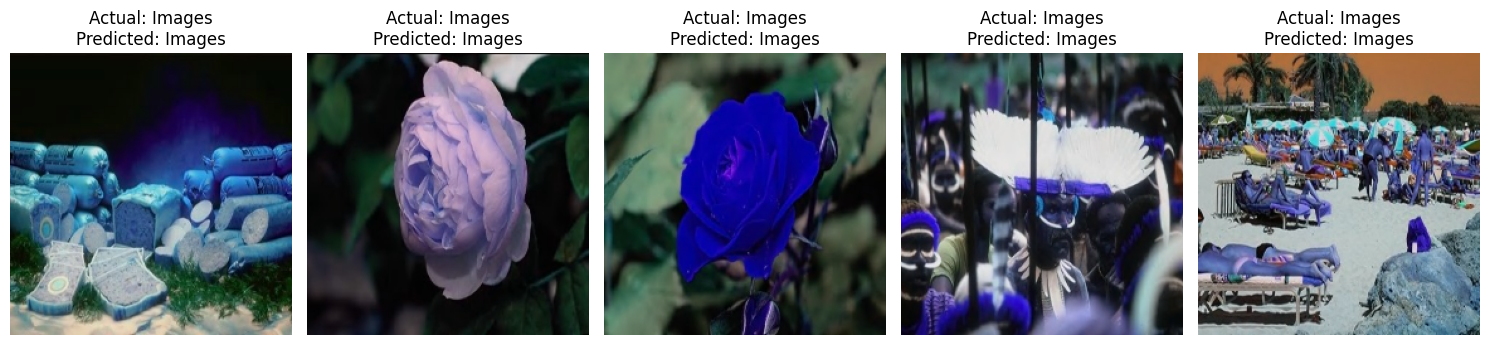

In [11]:
import matplotlib.pyplot as plt
import random


# Make predictions using the VGG16 model
predictions = vgg16.predict(resized_images_array)

# Get the predicted class for each image
predicted_classes_numerical = np.argmax(predictions, axis=1)

# Convert numerical predictions back to original labels
predicted_classes_labels = label_encoder.inverse_transform(predicted_classes_numerical)

# Visualize some predictions
num_samples_to_visualize = 5
random_indices = random.sample(range(len(resized_images_array)), num_samples_to_visualize)

plt.figure(figsize=(15, 10))
for i, idx in enumerate(random_indices):
    plt.subplot(1, num_samples_to_visualize, i + 1)
    plt.imshow(resized_images_array[idx])
    plt.title(f"Actual: {labels[idx]}\nPredicted: {predicted_classes_labels[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [12]:
# Display more predictions and their labels
print("\nMore Predictions:")
for i in range(min(10, len(resized_images_array))): # Display up to 10 more predictions
    print(f"Image {i+1}: Actual: {labels[i]}, Predicted: {predicted_classes_labels[i]}")


More Predictions:
Image 1: Actual: Images, Predicted: Images
Image 2: Actual: Images, Predicted: Images
Image 3: Actual: Images, Predicted: Images
Image 4: Actual: Images, Predicted: Images
Image 5: Actual: Images, Predicted: Images
Image 6: Actual: Images, Predicted: Images
Image 7: Actual: Images, Predicted: Images
Image 8: Actual: Images, Predicted: Images
Image 9: Actual: Images, Predicted: Images
Image 10: Actual: Images, Predicted: Images


In [44]:
import os
import cv2
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

# 1. Define dataset path
# Use the 'path' variable which contains the actual dataset location from kagglehub
dataset_path = path

# 2. Inspect classes (folders in dataset path)
class_names = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
class_names.sort()  # just to keep order consistent

print("Classes found in dataset:")
for i, c in enumerate(class_names):
    print(f"{i+1}. {c}")

# 3. Load images and labels manually (optional step, you can skip if using ImageDataGenerator)
images = []
labels = []

for label in class_names:
    class_folder = os.path.join(dataset_path, label)
    for img_file in os.listdir(class_folder):
        img_path = os.path.join(class_folder, img_file)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, (224, 224))  # resize to 224x224 for VGG16
            images.append(img)
            labels.append(label)

print(f"Loaded {len(images)} images with {len(set(labels))} unique labels.")

# Convert labels to numeric (optional, if you want)
label_to_index = {name: idx for idx, name in enumerate(class_names)}
numeric_labels = [label_to_index[l] for l in labels]

# Create a DataFrame to show image-label pairs (just for display)
df = pd.DataFrame({'Label': labels})
print(df['Label'].value_counts())  # show count per class

# 4. Using ImageDataGenerator to load images from directory with augmentation & preprocess_input

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.25  # 75% train, 25% validation split
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

# Show classes mapping (class indices)
print("Class indices:")
print(train_generator.class_indices)

# Optional: Make a table of classes with counts from train_generator
train_classes, train_counts = np.unique(train_generator.classes, return_counts=True)
class_labels = list(train_generator.class_indices.keys())
print("\nTraining set class distribution:")
for idx, count in zip(train_classes, train_counts):
    print(f"{class_labels[idx]}: {count} images")

print("\nValidation set class distribution:")
val_classes, val_counts = np.unique(validation_generator.classes, return_counts=True)
for idx, count in zip(val_classes, val_counts):
    print(f"{class_labels[idx]}: {count} images")

Classes found in dataset:
1. Images
2. wangdataset
Loaded 1000 images with 1 unique labels.
Label
Images    1000
Name: count, dtype: int64
Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Class indices:
{'Images': 0, 'wangdataset': 1}

Training set class distribution:
Images: 750 images
wangdataset: 750 images

Validation set class distribution:
Images: 250 images
wangdataset: 250 images


In [49]:
# Assuming 'vgg16' model is defined and 'train_generator', 'validation_generator' are ready

# Compile the model
vgg16.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
# You can adjust the number of epochs based on your needs
epochs = 10
history = vgg16.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size
)

# The 'history' object contains the training metrics
print("Training complete. History object available.")

Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4966 - loss: 744.2969

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


46/46 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.4967 - loss: 733.0120 - val_accuracy: 0.5208 - val_loss: 0.6929
Epoch 2/10
 1/46 ━━━━━━━━━━━━━━━━━━━━ 22s 494ms/step - accuracy: 0.4062 - loss: 0.6949

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 131ms/step - accuracy: 0.4062 - loss: 0.6949 - val_accuracy: 0.5042 - val_loss: 0.6932
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 34s 732ms/step - accuracy: 0.4730 - loss: 0.6949 - val_accuracy: 0.4792 - val_loss: 0.6934
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 131ms/step - accuracy: 0.4062 - loss: 0.6942 - val_accuracy: 0.4792 - val_loss: 0.6933
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 34s 728ms/step - accuracy: 0.4674 - loss: 0.6937 - val_accuracy: 0.5208 - val_loss: 0.6927
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 130ms/step - accuracy: 0.2812 - loss: 0.6984 - val_accuracy: 0.5208 - val_loss: 0.6927
Epoch 7/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 34s 727ms/step - accuracy: 0.5110 - loss: 0.6931 - val_accuracy: 0.4792 - val_loss: 0.6932
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 133ms/step - accuracy: 0.3125 - loss: 0.6935 - val_accuracy: 0.4792 - val_loss: 0.6932
Epoch 9/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 33s 724ms/step - accuracy: 0.4956 - loss: 0.6932 - val_accuracy: 0.5208 - 

Generating training history plots...


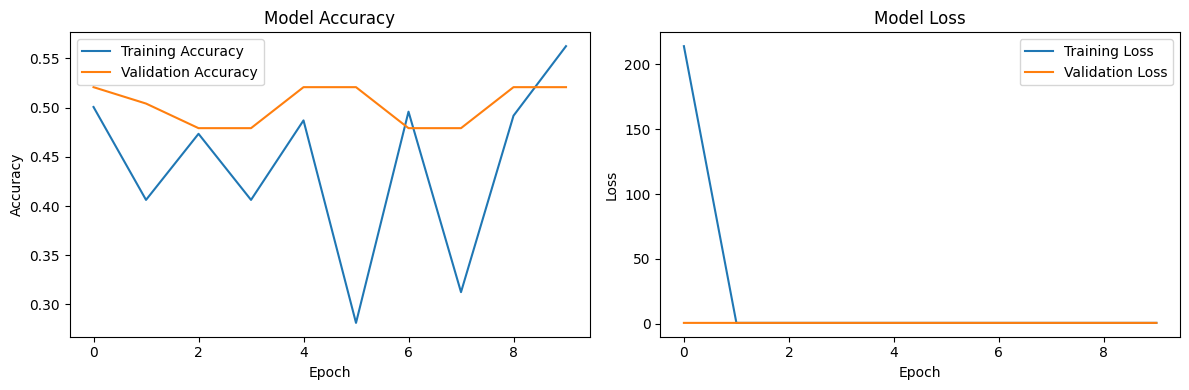

Training history plots generated.

Evaluating model on validation data...
16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.8039 - loss: 0.6924
Validation Loss: 0.6931
Validation Accuracy: 0.5000

Generating Confusion Matrix and Classification Report...
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 434ms/step


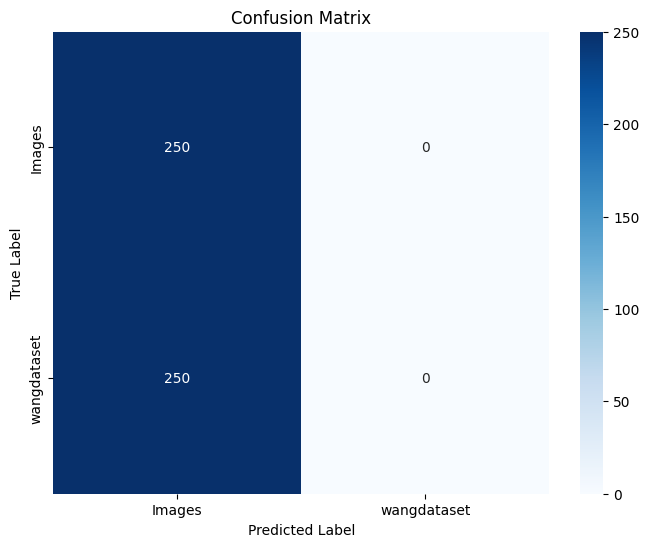

Confusion Matrix generated.

Classification Report:
              precision    recall  f1-score   support

      Images       0.50      1.00      0.67       250
 wangdataset       0.00      0.00      0.00       250

    accuracy                           0.50       500
   macro avg       0.25      0.50      0.33       500
weighted avg       0.25      0.50      0.33       500

Classification Report generated.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Visualize Training History (Accuracy and Loss)
print("Generating training history plots...")
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()
print("Training history plots generated.")


# 2. Evaluate the model on the validation data
print("\nEvaluating model on validation data...")
validation_loss, validation_accuracy = vgg16.evaluate(validation_generator) # Removed steps
print(f"Validation Loss: {validation_loss:.4f}")
print(f"Validation Accuracy: {validation_accuracy:.4f}")


# 3. Generate Confusion Matrix and Classification Report
print("\nGenerating Confusion Matrix and Classification Report...")

# Get predictions for the validation data
# Reset the validation generator to ensure predictions are in the correct order
validation_generator.reset()
predictions = vgg16.predict(validation_generator) # Removed steps
predicted_classes_numerical = np.argmax(predictions, axis=1)

# Get true labels for the validation data
# Ensure the number of true labels matches the number of predictions
true_classes_numerical = validation_generator.classes[:len(predicted_classes_numerical)]

# Get class labels from the generator
class_labels = list(validation_generator.class_indices.keys())

# Compute Confusion Matrix
cm = confusion_matrix(true_classes_numerical, predicted_classes_numerical)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
print("Confusion Matrix generated.")


# Generate Classification Report
print("\nClassification Report:")
print(classification_report(true_classes_numerical, predicted_classes_numerical, target_names=class_labels))
print("Classification Report generated.")

32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 186ms/step


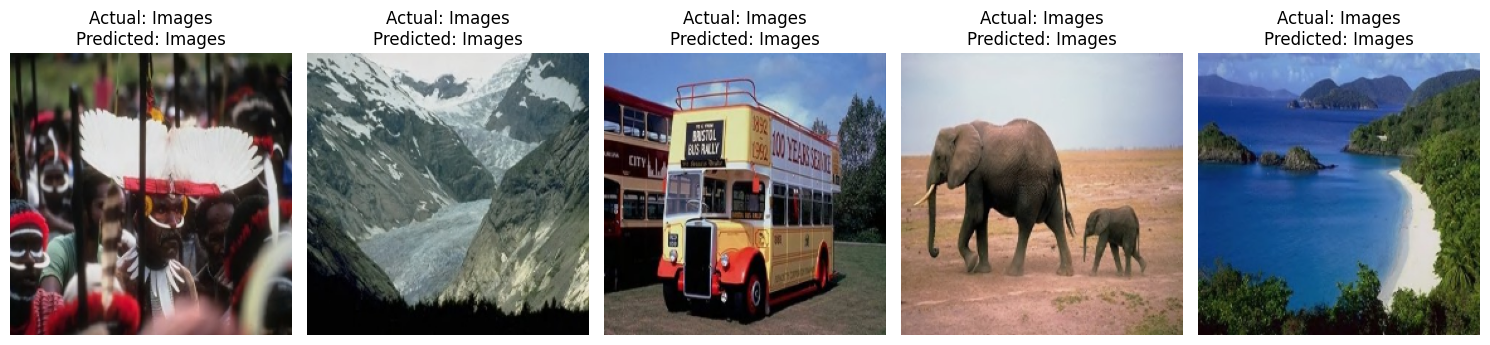

In [52]:
import matplotlib.pyplot as plt
import random
import numpy as np # Import numpy

# Assuming 'vgg16' model is already defined and loaded (from a previous cell)
# Assuming 'resized_images_array' and 'labels' are available (from previous cells)
# Assuming 'label_encoder' is available (from a previous cell)

# Make predictions using the VGG16 model
predictions = vgg16.predict(resized_images_array)

# Get the predicted class for each image
predicted_classes_numerical = np.argmax(predictions, axis=1)

# Convert numerical predictions back to original labels
predicted_classes_labels = label_encoder.inverse_transform(predicted_classes_numerical)

# Visualize some predictions
num_samples_to_visualize = 5
# Ensure that num_samples_to_visualize does not exceed the number of available images
num_samples_to_visualize = min(num_samples_to_visualize, len(resized_images_array))

if num_samples_to_visualize > 0:
    random_indices = random.sample(range(len(resized_images_array)), num_samples_to_visualize)

    plt.figure(figsize=(15, 10))
    for i, idx in enumerate(random_indices):
        plt.subplot(1, num_samples_to_visualize, i + 1)
        # Display the image - ensure the color channels are in the correct order (RGB)
        # If the original images were loaded with OpenCV (BGR), convert to RGB
        img_to_display = cv2.cvtColor(resized_images_array[idx], cv2.COLOR_BGR2RGB) if resized_images_array[idx].shape[-1] == 3 else resized_images_array[idx]
        plt.imshow(img_to_display)
        plt.title(f"Actual: {labels[idx]}\nPredicted: {predicted_classes_labels[idx]}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No images available to visualize.")

Saving download.jpg to download.jpg
Using VGG16 preprocess_input.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


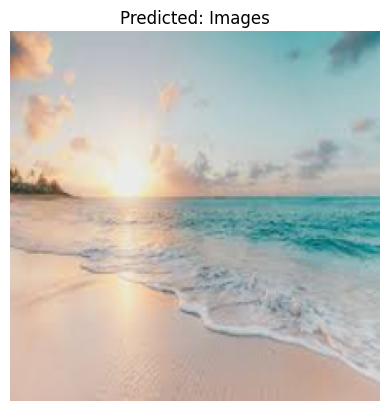

The model predicts this image belongs to the class: Images


In [54]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Assuming 'vgg16' model is already defined and loaded (from a previous cell)
# Assuming 'label_encoder' is available (from a previous cell)
# Assuming IMAGE_SIZE is defined (e.g., IMAGE_SIZE = (224, 224))

# Upload an image
uploaded = files.upload()

for fn in uploaded.keys():
    # Load and preprocess the image
    img = Image.open(fn).convert('RGB')
    img_resized = img.resize(IMAGE_SIZE)
    img_array = np.array(img_resized)

    # Ensure the image array has the correct shape and data type for the model
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
    img_array = img_array.astype('float32') # Ensure float32 data type

    # Preprocess the image using the VGG16 preprocess_input function
    # This is important if the model was trained with this preprocessing
    # Check if preprocess_input is available, otherwise skip or use a default scaling
    try:
        from tensorflow.keras.applications.vgg16 import preprocess_input
        img_preprocessed = preprocess_input(img_array)
        print("Using VGG16 preprocess_input.")
    except ImportError:
        print("VGG16 preprocess_input not available. Scaling pixel values to [0, 1].")
        img_preprocessed = img_array / 255.0 # Simple scaling if preprocess_input is not found


    # Make a prediction
    predictions = vgg16.predict(img_preprocessed)
    predicted_class_numerical = np.argmax(predictions, axis=1)
    predicted_class_label = label_encoder.inverse_transform(predicted_class_numerical)

    # Display the image and prediction
    plt.imshow(img_resized) # Display the resized image
    plt.title(f"Predicted: {predicted_class_label[0]}")
    plt.axis('off')
    plt.show()

    print(f"The model predicts this image belongs to the class: {predicted_class_label[0]}")

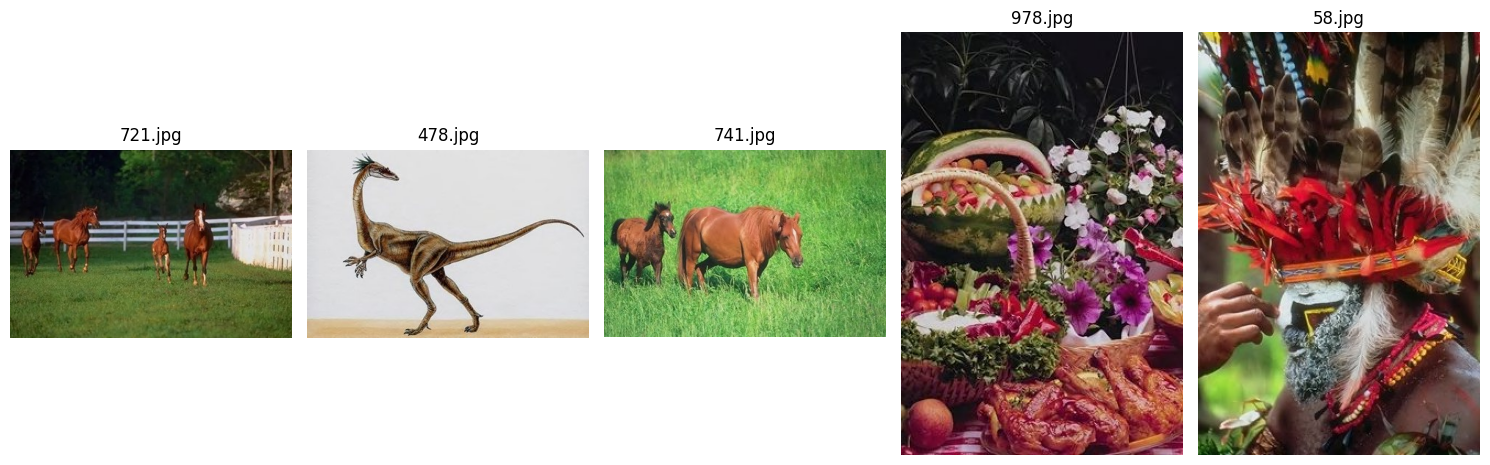

In [56]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Assuming 'path' variable contains the dataset directory path

def display_random_images(dataset_path, num_images=5):
    """
    Displays a few random images from the dataset directory.
    """
    all_image_paths = []
    for root, _, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print("No image files found in the dataset directory.")
        return

    num_images_to_display = min(num_images, len(all_image_paths))
    random_image_paths = random.sample(all_image_paths, num_images_to_display)

    plt.figure(figsize=(15, 5))
    for i, img_path in enumerate(random_image_paths):
        try:
            img = Image.open(img_path)
            plt.subplot(1, num_images_to_display, i + 1)
            plt.imshow(img)
            plt.title(os.path.basename(img_path))
            plt.axis('off')
        except Exception as e:
            print(f"Could not open image {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Display 5 random images from the dataset
display_random_images(path, num_images=5)